In [88]:
import pandas as pd
import numpy as np

path = "G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/509sf26-80_smote_outliers_n625_20250617_140255"
path2 = "G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data/"
path3 = "G:/共有ドライブ/GAP_長寿研/認知機能データ"

eye_movement: (872, 71)
読み込み完了！


In [89]:

df = pd.read_csv(f"{path2}/全長文字_minirocket.csv")





df1= pd.read_csv(f"{path2}/正規化ncgg.csv")



In [83]:
df.head()

,coordinate_transform_applied,left_eye_ratio,velocity_x_spectral_centroid,velocity_x_low_mid_ratio,velocity_x_mid_high_ratio,velocity_x_low_high_ratio,velocity_x_low_power_ratio,velocity_x_mid_power_ratio,velocity_x_high_power_ratio,velocity_x_spectral_entropy,...,minirocket_acceleration_magnitude_f096,minirocket_acceleration_magnitude_f097,minirocket_acceleration_magnitude_f098,minirocket_acceleration_magnitude_f099,minirocket_enabled,minirocket_implementation,minirocket_kernels,minirocket_features_count,folder_name,subject_id
0,True,0.966300,2.694308,1.047909,4.703983e+09,4.929344e+09,0.511697,0.488303,0.000000,8.635939,...,1,0,1,1,True,simple,100,600,20241009101605_1,20241009101605_1
1,True,0.998586,1.664879,2.728058,2.618130e+09,7.142411e+09,0.731764,0.268236,0.000000,7.991916,...,0,1,0,0,True,simple,100,600,20241009101953_2,20241009101953_2
2,True,0.940358,2.975514,0.750769,5.549960e+09,4.166738e+09,0.428822,0.571178,0.000000,8.824532,...,0,0,1,1,True,simple,100,600,20241009102622_3,20241009102622_3
3,True,0.043393,26.884914,0.039061,1.652914e-01,6.456432e-03,0.005510,0.141064,0.853426,8.349578,...,1,0,1,1,True,simple,100,600,20241009103059_5,20241009103059_5
4,True,0.266182,4.271527,0.280895,7.789433e+09,2.188011e+09,0.219296,0.780704,0.000000,8.982306,...,0,1,1,1,True,simple,100,600,20241009103234_6,20241009103234_6


In [84]:
df1.head()

,InspectionDateAndId,kioku,cyui,zikko,syori,sum
0,20241009101605_1,4,3,4,5,16
1,20241009101953_2,4,3,4,5,16
2,20241009102622_3,3,2,4,4,13
3,20241009103315_7,3,2,1,3,9
4,20241009104009_10,3,2,1,3,9


In [90]:
df2 = pd.read_csv(f"{path2}/長寿文字drive.csv")

In [86]:
df2.head()

,InspectionDateAndId,Drive_frequency_now,Drive_AT_or_MT,education,sex
0,20241009101605_1,8888.0,8888,9,1
1,20241009101953_2,8888.0,8888,9,1
2,20241009102622_3,7.0,1,12,2
3,20241009103315_7,7.0,1,13,2
4,20241009104009_10,7.0,1,13,2


In [91]:
dfs=pd.merge(df, df1, on ='InspectionDateAndId', how = 'inner')

In [92]:
df3s=pd.merge(dfs, df2, on = 'InspectionDateAndId', how = 'inner')

In [93]:
df3s.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\minirocket長文字正規化点.csv')

In [18]:

dfs['education_centered'] = dfs['EducationYear'] - dfs['EducationYear'].mean()
dfs['age_edu_interaction'] = dfs['Age^'] * dfs['education_centered']

KeyError: 'Age^'

In [16]:
dfs.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\features_0714_性別_edu.csv')

In [28]:
df3s.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\長文字eye_movement_features_小.csv')

In [21]:
# 1. dfのカラム名をリストに格納
columns_list = df2.columns.tolist()

# 2. 特定のカラムのみを選択したい場合
# 例：最初の10個のカラム
selected_columns = df2.columns[:10].tolist()

# 例：特定のパターンを含むカラムを選択
latency_columns = [col for col in df2.columns if 'Latency' in col]
saccade_columns = [col for col in df2.columns if 'Saccade' in col]
velocity_columns = [col for col in df2.columns if 'Velocity' in col]

# 3. 基本カラム（ID、target、Age）と特定の測定値カラムを組み合わせ
basic_columns = ['InspectionDateAndId', 'target', 'Age']
analysis_columns = basic_columns + latency_columns[:5]  # 最初の5つのLatencyカラム

# 4. 別のデータフレームから同じカラムを選択
# 例：df2という別のデータフレームがある場合
# 全カラムを使用
# dfs1 = df.copy()
# dfs2 = df2[columns_list]  # df2から同じカラムを選択

# 特定のカラムを使用
# dfs1 = df[selected_columns]
# dfs2 = df2[selected_columns]

# 分析用カラムを使用
# dfs1 = df[analysis_columns]
# dfs2 = df2[analysis_columns]

# 5. 関数として定義（再利用可能）
def select_columns_from_dataframe(dataframe, column_list):
    """
    指定されたカラムリストを使用してデータフレームから列を選択
    
    Parameters:
    dataframe: 元のデータフレーム
    column_list: 選択したいカラム名のリスト
    
    Returns:
    選択されたカラムを持つ新しいデータフレーム
    """
    # データフレームに存在するカラムのみを選択
    existing_columns = [col for col in column_list if col in dataframe.columns]
    return dataframe[existing_columns].copy()

# 使用例：
# dfs1 = select_columns_from_dataframe(df, columns_list)
# dfs2 = select_columns_from_dataframe(df2, columns_list)

# 6. カラムの保存と読み込み - エラー修正版
import json
import os

try:
    # ユーザーのホームディレクトリに保存
    home_dir = os.path.expanduser("~")
    file_path = os.path.join(home_dir, "column_names.json")
    
    # カラムリストをファイルに保存
    with open(file_path, 'w') as f:
        json.dump(columns_list, f)
    print(f"カラムリストを保存しました: {file_path}")
    
    # カラムリストをファイルから読み込み
    with open(file_path, 'r') as f:
        loaded_columns = json.load(f)
    print(f"カラムリストを読み込みました: {len(loaded_columns)}個のカラム")
    
    # 読み込んだカラムリストを使用
    # dfs = df[loaded_columns]
    
except OSError as e:
    print(f"ファイル操作エラー: {e}")
    print("代替方法: 変数にカラムリストを保持します")
    # 変数として保持する場合の代替コード
    selected_columns_dict = {
        "all_columns": columns_list,
        "basic": basic_columns,
        "latency": latency_columns,
        "saccade": saccade_columns,
        "velocity": velocity_columns,
        "analysis": analysis_columns
    }

カラムリストを保存しました: C:\Users\user\column_names.json
カラムリストを読み込みました: 422個のカラム


In [21]:
dfs = df3[loaded_columns]

In [11]:
metadata = pd.read_csv("G:/共有ドライブ/MCI/MoCA/2023/metadata.csv", encoding='shift-jis')
metadata['InspectionDateAndId'] = [x.split('/')[-1].split('.')[0] for x in metadata['ins_path']]
all_features = pd.merge(df3,metadata,how='left',on=['InspectionDateAndId'])

In [12]:
all_features.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\509smallleft.csv')

In [ ]:
df23=pd.merge(df, df3, on = 'PublicId', how = 'inner')

In [4]:
dfs=pd.merge(df, df2, on = 'InspectionDateAndId', how = 'inner')

In [5]:
dfs.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\features_0515sf26.csv')

In [18]:
df02.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\meta_combined_saccade_analysis_15k小.csv')

In [ ]:
dfs = df2[[
    # レイテンシー関連
    'LatencyMax', 
    'CalibrationLatencyMean', 
    'LatencyMaxIsError1',
    
    # 応答時間関連
    'ResponseTimeMaxDistanceFlg2',
    'ResponseTimeMaxDistanceFlg1',
    'ResponseTimeMaxDistanceFlg0',
    
    # サッカード関連
    'SaccadeCountMaxDistanceFlg0',
    'CalibrationFixationSaccadeCountMean',
    'CalibrationPursuingSaccadeCountMean',
    'CalibrationFixationSaccadeWidthMaxMax',
    
    'SaccadeWidthMaxMeanIsError1',
    'SaccadeWidthSumMaxIsError1',
    'SaccadeWidthSumMaxDistanceFlg1',
    'SaccadeWidthSumMeanIsError1',
    
    # 速度関連
    'VelocityMaxMaxIsError1',
    'VelocityMaxMax',
    'VelocityMaxMaxDistanceFlg2',
    
    # 瞳孔サイズ変化率関連
    'PupilSizeChangeRateMax',
    'PupilSizeChangeRateMaxIsError1',
    'PupilSizeChangeRateMaxDistanceFlg1'
]]

In [25]:
dfs = df2[[
    'InspectionDateAndId',
    'MoCA',
    'Age',
    'Latency3.0_-3.0', 
    'SaccadeCount3.0_-3.0', 
    'SaccadeWidthMax3.0_-3.0', 
    'SaccadeWidthSum3.0_-3.0', 
    'VelocityMax3.0_-3.0', 
    'PupilSizeChangeRate3.0_-3.0', 
    'Latency21.0_-3.0', 
    'SaccadeCount21.0_-3.0', 
    'SaccadeWidthMax21.0_-3.0', 
    'SaccadeWidthSum21.0_-3.0', 
    'VelocityMax21.0_-3.0', 
    'DegreeDiff21.0_-3.0', 
    'PupilSizeChangeRate21.0_-3.0', 
    'Latency-9.0_-9.0', 
    'ResponseTime-9.0_-9.0', 
    'SaccadeCount-9.0_-9.0', 
    'SaccadeWidthMax-9.0_-9.0', 
    'SaccadeWidthSum-9.0_-9.0', 
    'VelocityMax-9.0_-9.0', 
    'DegreeDiff-9.0_-9.0', 
    'PupilSizeChangeRate-9.0_-9.0', 
    'Latency3.0_3.0', 
    'SaccadeCount3.0_3.0', 
    'SaccadeWidthMax3.0_3.0', 
    'SaccadeWidthSum3.0_3.0', 
    'VelocityMax3.0_3.0', 
    'PupilSizeChangeRate3.0_3.0', 
    'Latency-15.0_3.0', 
    'ResponseTime-15.0_3.0', 
    'SaccadeCount-15.0_3.0', 
    'SaccadeWidthMax-15.0_3.0', 
    'SaccadeWidthSum-15.0_3.0', 
    'VelocityMax-15.0_3.0', 
    'DegreeDiff-15.0_3.0', 
    'PupilSizeChangeRate-15.0_3.0', 
    'Latency9.0_3.0', 
    'ResponseTime9.0_3.0', 
    'SaccadeCount9.0_3.0', 
    'SaccadeWidthMax9.0_3.0', 
    'SaccadeWidthSum9.0_3.0', 
    'VelocityMax9.0_3.0', 
    'DegreeDiff9.0_3.0', 
    'PupilSizeChangeRate9.0_3.0', 
    'Latency9.0_9.0', 
    'ResponseTime9.0_9.0', 
    'SaccadeCount9.0_9.0', 
    'SaccadeWidthMax9.0_9.0', 
    'SaccadeWidthSum9.0_9.0', 
    'VelocityMax9.0_9.0', 
    'DegreeDiff9.0_9.0', 
    'PupilSizeChangeRate9.0_9.0', 
    'Latency-3.0_9.0', 
    'ResponseTime-3.0_9.0', 
    'SaccadeCount-3.0_9.0', 
    'SaccadeWidthMax-3.0_9.0', 
    'SaccadeWidthSum-3.0_9.0', 
    'VelocityMax-3.0_9.0', 
    'DegreeDiff-3.0_9.0', 
    'PupilSizeChangeRate-3.0_9.0', 
    'Latency-15.0_-3.0', 
    'ResponseTime-15.0_-3.0', 
    'SaccadeCount-15.0_-3.0', 
    'SaccadeWidthMax-15.0_-3.0', 
    'SaccadeWidthSum-15.0_-3.0', 
    'VelocityMax-15.0_-3.0', 
    'DegreeDiff-15.0_-3.0', 
    'PupilSizeChangeRate-15.0_-3.0', 
    'Latency3.0_-21.0', 
    'ResponseTime3.0_-21.0', 
    'SaccadeCount3.0_-21.0', 
    'SaccadeWidthMax3.0_-21.0', 
    'SaccadeWidthSum3.0_-21.0', 
    'VelocityMax3.0_-21.0', 
    'DegreeDiff3.0_-21.0', 
    'PupilSizeChangeRate3.0_-21.0', 
    'Latency3.0_15.0', 
    'SaccadeCount3.0_15.0', 
    'SaccadeWidthMax3.0_15.0', 
    'SaccadeWidthSum3.0_15.0', 
    'VelocityMax3.0_15.0', 
    'DegreeDiff3.0_15.0', 
    'PupilSizeChangeRate3.0_15.0', 
    'Latency-3.0_-15.0', 
    'ResponseTime-3.0_-15.0', 
    'SaccadeCount-3.0_-15.0', 
    'SaccadeWidthMax-3.0_-15.0', 
    'SaccadeWidthSum-3.0_-15.0', 
    'VelocityMax-3.0_-15.0', 
    'DegreeDiff-3.0_-15.0', 
    'PupilSizeChangeRate-3.0_-15.0', 
    'Latency9.0_15.0', 
    'SaccadeCount9.0_15.0', 
    'SaccadeWidthMax9.0_15.0', 
    'SaccadeWidthSum9.0_15.0', 
    'VelocityMax9.0_15.0', 
    'DegreeDiff9.0_15.0', 
    'PupilSizeChangeRate9.0_15.0', 
    'Latency-9.0_9.0', 
    'ResponseTime-9.0_9.0', 
    'SaccadeCount-9.0_9.0', 
    'SaccadeWidthMax-9.0_9.0', 
    'SaccadeWidthSum-9.0_9.0', 
    'VelocityMax-9.0_9.0', 
    'DegreeDiff-9.0_9.0', 
    'PupilSizeChangeRate-9.0_9.0', 
    'Latency-9.0_-21.0', 
    'SaccadeCount-9.0_-21.0', 
    'SaccadeWidthMax-9.0_-21.0', 
    'SaccadeWidthSum-9.0_-21.0', 
    'VelocityMax-9.0_-21.0', 
    'DegreeDiff-9.0_-21.0', 
    'PupilSizeChangeRate-9.0_-21.0', 
    'Latency3.0_21.0', 
    'SaccadeCount3.0_21.0', 
    'SaccadeWidthMax3.0_21.0', 
    'SaccadeWidthSum3.0_21.0', 
    'VelocityMax3.0_21.0', 
    'DegreeDiff3.0_21.0', 
    'PupilSizeChangeRate3.0_21.0', 
    'Latency9.0_-9.0', 
    'ResponseTime9.0_-9.0', 
    'SaccadeCount9.0_-9.0', 
    'SaccadeWidthMax9.0_-9.0', 
    'SaccadeWidthSum9.0_-9.0', 
    'VelocityMax9.0_-9.0', 
    'DegreeDiff9.0_-9.0', 
    'PupilSizeChangeRate9.0_-9.0', 
    'Latency-3.0_3.0', 
    'SaccadeCount-3.0_3.0', 
    'SaccadeWidthMax-3.0_3.0', 
    'SaccadeWidthSum-3.0_3.0', 
    'VelocityMax-3.0_3.0', 
    'PupilSizeChangeRate-3.0_3.0', 
    'Latency-15.0_9.0', 
    'ResponseTime-15.0_9.0', 
    'SaccadeCount-15.0_9.0', 
    'SaccadeWidthMax-15.0_9.0', 
    'SaccadeWidthSum-15.0_9.0', 
    'VelocityMax-15.0_9.0', 
    'DegreeDiff-15.0_9.0', 
    'PupilSizeChangeRate-15.0_9.0', 
    'Latency15.0_-9.0', 
    'SaccadeCount15.0_-9.0', 
    'SaccadeWidthMax15.0_-9.0', 
    'SaccadeWidthSum15.0_-9.0', 
    'VelocityMax15.0_-9.0', 
    'DegreeDiff15.0_-9.0', 
    'PupilSizeChangeRate15.0_-9.0', 
    'Latency3.0_-15.0', 
    'SaccadeCount3.0_-15.0', 
    'SaccadeWidthMax3.0_-15.0', 
    'SaccadeWidthSum3.0_-15.0', 
    'VelocityMax3.0_-15.0', 
    'DegreeDiff3.0_-15.0', 
    'PupilSizeChangeRate3.0_-15.0', 
    'Latency-3.0_21.0', 
    'SaccadeCount-3.0_21.0', 
    'SaccadeWidthMax-3.0_21.0', 
    'SaccadeWidthSum-3.0_21.0', 
    'VelocityMax-3.0_21.0', 
    'DegreeDiff-3.0_21.0', 
    'PupilSizeChangeRate-3.0_21.0', 
    'Latency3.0_-9.0', 
    'ResponseTime3.0_-9.0', 
    'SaccadeCount3.0_-9.0', 
    'SaccadeWidthMax3.0_-9.0', 
    'SaccadeWidthSum3.0_-9.0', 
    'VelocityMax3.0_-9.0', 
    'DegreeDiff3.0_-9.0', 
    'PupilSizeChangeRate3.0_-9.0', 
    'Latency-21.0_9.0', 
    'SaccadeCount-21.0_9.0', 
    'SaccadeWidthMax-21.0_9.0', 
    'SaccadeWidthSum-21.0_9.0', 
    'VelocityMax-21.0_9.0', 
    'DegreeDiff-21.0_9.0', 
    'PupilSizeChangeRate-21.0_9.0', 
    'Latency9.0_-21.0', 
    'ResponseTime9.0_-21.0', 
    'SaccadeCount9.0_-21.0', 
    'SaccadeWidthMax9.0_-21.0', 
    'SaccadeWidthSum9.0_-21.0', 
    'VelocityMax9.0_-21.0', 
    'DegreeDiff9.0_-21.0', 
    'PupilSizeChangeRate9.0_-21.0', 
    'Latency-9.0_15.0', 
    'ResponseTime-9.0_15.0', 
    'SaccadeCount-9.0_15.0', 
    'SaccadeWidthMax-9.0_15.0', 
    'SaccadeWidthSum-9.0_15.0', 
    'VelocityMax-9.0_15.0', 
    'DegreeDiff-9.0_15.0', 
    'PupilSizeChangeRate-9.0_15.0', 
    'Latency21.0_3.0', 
    'SaccadeCount21.0_3.0', 
    'SaccadeWidthMax21.0_3.0', 
    'SaccadeWidthSum21.0_3.0', 
    'VelocityMax21.0_3.0', 
    'DegreeDiff21.0_3.0', 
    'PupilSizeChangeRate21.0_3.0', 
    'Latency-21.0_3.0', 
    'SaccadeCount-21.0_3.0', 
    'SaccadeWidthMax-21.0_3.0', 
    'SaccadeWidthSum-21.0_3.0', 
    'VelocityMax-21.0_3.0', 
    'DegreeDiff-21.0_3.0', 
    'PupilSizeChangeRate-21.0_3.0', 
    'Latency15.0_3.0', 
    'SaccadeCount15.0_3.0', 
    'SaccadeWidthMax15.0_3.0', 
    'SaccadeWidthSum15.0_3.0', 
    'VelocityMax15.0_3.0', 
    'DegreeDiff15.0_3.0', 
    'PupilSizeChangeRate15.0_3.0', 
    'Latency-3.0_-3.0', 
    'SaccadeCount-3.0_-3.0', 
    'SaccadeWidthMax-3.0_-3.0', 
    'SaccadeWidthSum-3.0_-3.0', 
    'VelocityMax-3.0_-3.0', 
    'PupilSizeChangeRate-3.0_-3.0', 
    'Latency9.0_-3.0', 
    'ResponseTime9.0_-3.0', 
    'SaccadeCount9.0_-3.0', 
    'SaccadeWidthMax9.0_-3.0', 
    'SaccadeWidthSum9.0_-3.0', 
    'VelocityMax9.0_-3.0', 
    'DegreeDiff9.0_-3.0', 
    'PupilSizeChangeRate9.0_-3.0', 
    'Latency-21.0_-3.0', 
    'SaccadeCount-21.0_-3.0', 
    'SaccadeWidthMax-21.0_-3.0', 
    'SaccadeWidthSum-21.0_-3.0', 
    'VelocityMax-21.0_-3.0', 
    'DegreeDiff-21.0_-3.0', 
    'PupilSizeChangeRate-21.0_-3.0', 
    'Latency-3.0_-9.0', 
    'ResponseTime-3.0_-9.0', 
    'SaccadeCount-3.0_-9.0', 
    'SaccadeWidthMax-3.0_-9.0', 
    'SaccadeWidthSum-3.0_-9.0', 
    'VelocityMax-3.0_-9.0', 
    'DegreeDiff-3.0_-9.0', 
    'PupilSizeChangeRate-3.0_-9.0', 
    'Latency3.0_9.0', 
    'SaccadeCount3.0_9.0', 
    'SaccadeWidthMax3.0_9.0', 
    'SaccadeWidthSum3.0_9.0', 
    'VelocityMax3.0_9.0', 
    'PupilSizeChangeRate3.0_9.0', 
    'Latency15.0_-15.0', 
    'ResponseTime15.0_-15.0', 
    'SaccadeCount15.0_-15.0', 
    'SaccadeWidthMax15.0_-15.0', 
    'SaccadeWidthSum15.0_-15.0', 
    'VelocityMax15.0_-15.0', 
    'DegreeDiff15.0_-15.0', 
    'PupilSizeChangeRate15.0_-15.0', 
    'Latency-9.0_21.0', 
    'SaccadeCount-9.0_21.0', 
    'SaccadeWidthMax-9.0_21.0', 
    'SaccadeWidthSum-9.0_21.0', 
    'VelocityMax-9.0_21.0', 
    'DegreeDiff-9.0_21.0', 
    'PupilSizeChangeRate-9.0_21.0', 
    'Latency-9.0_-3.0', 
    'ResponseTime-9.0_-3.0', 
    'SaccadeCount-9.0_-3.0', 
    'SaccadeWidthMax-9.0_-3.0', 
    'SaccadeWidthSum-9.0_-3.0', 
    'VelocityMax-9.0_-3.0', 
    'DegreeDiff-9.0_-3.0', 
    'PupilSizeChangeRate-9.0_-3.0', 
    'Latency15.0_9.0', 
    'SaccadeCount15.0_9.0', 
    'SaccadeWidthMax15.0_9.0', 
    'SaccadeWidthSum15.0_9.0', 
    'VelocityMax15.0_9.0', 
    'DegreeDiff15.0_9.0', 
    'PupilSizeChangeRate15.0_9.0', 
    'Latency-15.0_-15.0', 
    'SaccadeCount-15.0_-15.0', 
    'SaccadeWidthMax-15.0_-15.0', 
    'SaccadeWidthSum-15.0_-15.0', 
    'VelocityMax-15.0_-15.0', 
    'DegreeDiff-15.0_-15.0', 
    'PupilSizeChangeRate-15.0_-15.0', 
    'Latency15.0_15.0', 
    'ResponseTime15.0_15.0', 
    'SaccadeCount15.0_15.0', 
    'SaccadeWidthMax15.0_15.0', 
    'SaccadeWidthSum15.0_15.0', 
    'VelocityMax15.0_15.0', 
    'DegreeDiff15.0_15.0', 
    'PupilSizeChangeRate15.0_15.0', 
    'Latency-9.0_-15.0', 
    'ResponseTime-9.0_-15.0', 
    'SaccadeCount-9.0_-15.0', 
    'SaccadeWidthMax-9.0_-15.0', 
    'SaccadeWidthSum-9.0_-15.0', 
    'VelocityMax-9.0_-15.0', 
    'DegreeDiff-9.0_-15.0', 
    'PupilSizeChangeRate-9.0_-15.0', 
    'Latency-9.0_3.0', 
    'ResponseTime-9.0_3.0', 
    'SaccadeCount-9.0_3.0', 
    'SaccadeWidthMax-9.0_3.0', 
    'SaccadeWidthSum-9.0_3.0', 
    'VelocityMax-9.0_3.0', 
    'DegreeDiff-9.0_3.0', 
    'PupilSizeChangeRate-9.0_3.0', 
    'Latency-15.0_-9.0', 
    'ResponseTime-15.0_-9.0', 
    'SaccadeCount-15.0_-9.0', 
    'SaccadeWidthMax-15.0_-9.0', 
    'SaccadeWidthSum-15.0_-9.0', 
    'VelocityMax-15.0_-9.0', 
    'DegreeDiff-15.0_-9.0', 
    'PupilSizeChangeRate-15.0_-9.0', 
    'Latency9.0_-15.0', 
    'ResponseTime9.0_-15.0', 
    'SaccadeCount9.0_-15.0', 
    'SaccadeWidthMax9.0_-15.0', 
    'SaccadeWidthSum9.0_-15.0', 
    'VelocityMax9.0_-15.0', 
    'DegreeDiff9.0_-15.0', 
    'PupilSizeChangeRate9.0_-15.0', 
    'Latency15.0_-3.0', 
    'ResponseTime15.0_-3.0', 
    'SaccadeCount15.0_-3.0', 
    'SaccadeWidthMax15.0_-3.0', 
    'SaccadeWidthSum15.0_-3.0', 
    'VelocityMax15.0_-3.0', 
    'DegreeDiff15.0_-3.0', 
    'PupilSizeChangeRate15.0_-3.0', 
    'Latency-3.0_-21.0', 
    'SaccadeCount-3.0_-21.0', 
    'SaccadeWidthMax-3.0_-21.0', 
    'SaccadeWidthSum-3.0_-21.0', 
    'VelocityMax-3.0_-21.0', 
    'DegreeDiff-3.0_-21.0', 
    'PupilSizeChangeRate-3.0_-21.0', 
    'Latency21.0_-9.0', 
    'SaccadeCount21.0_-9.0', 
    'SaccadeWidthMax21.0_-9.0', 
    'SaccadeWidthSum21.0_-9.0', 
    'VelocityMax21.0_-9.0', 
    'DegreeDiff21.0_-9.0', 
    'PupilSizeChangeRate21.0_-9.0', 
    'Latency9.0_21.0', 
    'ResponseTime9.0_21.0', 
    'SaccadeCount9.0_21.0', 
    'SaccadeWidthMax9.0_21.0', 
    'SaccadeWidthSum9.0_21.0', 
    'VelocityMax9.0_21.0', 
    'DegreeDiff9.0_21.0', 
    'PupilSizeChangeRate9.0_21.0', 
    'Latency-21.0_-9.0', 
    'ResponseTime-21.0_-9.0', 
    'SaccadeCount-21.0_-9.0', 
    'SaccadeWidthMax-21.0_-9.0', 
    'SaccadeWidthSum-21.0_-9.0', 
    'VelocityMax-21.0_-9.0', 
    'DegreeDiff-21.0_-9.0', 
    'PupilSizeChangeRate-21.0_-9.0', 
    'Latency-3.0_15.0', 
    'SaccadeCount-3.0_15.0', 
    'SaccadeWidthMax-3.0_15.0', 
    'SaccadeWidthSum-3.0_15.0', 
    'VelocityMax-3.0_15.0', 
    'DegreeDiff-3.0_15.0', 
    'PupilSizeChangeRate-3.0_15.0', 
    'Latency21.0_9.0', 
    'ResponseTime21.0_9.0', 
    'SaccadeCount21.0_9.0', 
    'SaccadeWidthMax21.0_9.0', 
    'SaccadeWidthSum21.0_9.0', 
    'VelocityMax21.0_9.0', 
    'DegreeDiff21.0_9.0', 
    'PupilSizeChangeRate21.0_9.0', 
    'Latency-15.0_15.0', 
    'ResponseTime-15.0_15.0', 
    'SaccadeCount-15.0_15.0', 
    'SaccadeWidthMax-15.0_15.0', 
    'SaccadeWidthSum-15.0_15.0', 
    'VelocityMax-15.0_15.0', 
    'DegreeDiff-15.0_15.0', 
    'PupilSizeChangeRate-15.0_15.0'
]
]



In [26]:
dfs.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\509.csv')

In [11]:
import pandas as pd

# 例: CSVファイルからデータフレームを読み込む場合
# df = pd.read_csv('あなたのファイル.csv')
# または他の方法でデータフレームを読み込んだと仮定

# 選択したいカラム名のリスト（新たに3つのカラムを追加）
selected_columns = [
    'InspectionDateAndId', 'Age', 'target',  # 追加した3つのカラム
    'SaccadeWidthSumMean', 'SaccadeWidthMaxMean', 'GainMeanIsError0', 
    'GainDiffMeanIsError0', 'SaccadeWidthMaxMeanDistanceFlg1', 
    'SaccadeWidthSumMeanDistanceFlg2', 'SaccadeWidthSumMeanDistanceFlg1', 
    'VelocityMaxMean', 'SaccadeWidthMaxMeanDistanceFlg2', 'GainMeanDistanceFlg2', 
    'GainDiffMeanDistanceFlg2', 'VelocityMaxMeanDistanceFlg1', 
    'SaccadeWidthMaxMeanIsError0', 'SaccadeWidthSumMeanIsError0', 
    'GainMeanDistanceFlg1', 'VelocityMaxMeanDistanceFlg2', 
    'VelocityMaxMeanIsError0', 'SaccadeCountStd', 'GainDiffMeanDistanceFlg1', 
    'SaccadeCountMean', 'SaccadeWidthMaxMeanIsError1', 'ResponseTimeMeanIsError0', 
    'SaccadeWidthSumMeanIsError1', 'GainDiffStdIsError0', 'GainMinIsError0', 
    'ErrorRate', 'VelocityMaxMeanIsError1', 'SaccadeCountMaxIsError1', 
    'SaccadeWidthMaxMax', 'SaccadeCountMax', 'SaccadeCountStdDistanceFlg2', 
    'SaccadeCountMeanDistanceFlg2', 'SaccadeCountMeanDistanceFlg1', 
    'SaccadeCountStdDistanceFlg1', 'GainDiffMaxIsError0', 
    'ResponseTimeMeanDistanceFlg1', 'GainMinDistanceFlg1', 
    'SaccadeWidthMaxMaxDistanceFlg2', 'GainMinDistanceFlg2', 
    'LatencyMinIsError1', 'LatencyMin', 'GainDiffMaxDistanceFlg2', 
    'GainDiffMaxDistanceFlg1', 'GainMeanDistanceFlg0', 'VelocityMaxStd', 
    'GainDiffStdDistanceFlg1', 'ResponseTimeMeanDistanceFlg2', 
    'GainDiffStdDistanceFlg2', 'SaccadeWidthMaxStdDistanceFlg2', 
    'SaccadeWidthMaxStdDistanceFlg1', 'ResponseTimeStdDistanceFlg1', 
    'SaccadeCountStdDistanceFlg0', 'SaccadeWidthSumStdDistanceFlg1', 
    'VelocityMaxMax', 'SaccadeWidthMaxMaxDistanceFlg1', 
    'SaccadeCountMeanDistanceFlg0', 'SaccadeWidthMaxMaxIsError0', 
    'SaccadeWidthSumStd', 'VelocityMaxMaxDistanceFlg2', 'SaccadeWidthSumMax'
]

# データフレームから指定したカラムのみを選択
# 元のデータフレームに存在するカラムのみを選択するため、交差を取る
available_columns = list(set(df2.columns) & set(selected_columns))
df_selected = df2[available_columns]

# もし元のデータフレームに特定のカラムが存在しない場合のチェック
missing_columns = list(set(selected_columns) - set(df2.columns))
if missing_columns:
    print(f"警告: 次のカラムはデータフレームに存在しません: {missing_columns}")

# 結果の確認
print(f"選択されたカラム数: {len(df_selected.columns)}")
print(f"元のデータフレームのカラム数: {len(df2.columns)}")

選択されたカラム数: 63
元のデータフレームのカラム数: 211


In [12]:
df_selected.head()

,SaccadeCountStdDistanceFlg2,GainMeanDistanceFlg0,VelocityMaxMeanDistanceFlg2,SaccadeWidthSumMax,VelocityMaxMeanIsError0,GainDiffStdIsError0,ResponseTimeMeanIsError0,SaccadeWidthSumMeanIsError1,SaccadeCountStdDistanceFlg0,SaccadeWidthSumMean,...,SaccadeWidthSumMeanIsError0,GainDiffStdDistanceFlg1,GainMeanDistanceFlg2,VelocityMaxMax,SaccadeCountMeanDistanceFlg0,GainMeanIsError0,GainMinIsError0,SaccadeWidthMaxMax,VelocityMaxMeanIsError1,SaccadeCountMeanDistanceFlg2
0,0.510754,0.904708,0.346784,35.428935,0.290591,0.153188,297.617021,15.435345,0.000000,14.521875,...,14.385827,0.119155,0.791902,0.604832,1.000000,0.846638,0.506900,28.100722,0.361127,1.500000
1,0.442326,1.094287,0.375659,29.887118,0.299417,0.204743,303.789474,16.173583,0.301511,15.140457,...,14.678269,0.111039,0.793061,0.529884,1.090909,0.904757,0.186490,29.887118,0.335943,1.250000
2,0.387553,0.990439,0.369538,29.102015,0.299695,0.067581,277.600000,17.430561,0.000000,16.147356,...,15.947747,0.069447,0.913694,0.458301,1.000000,0.937956,0.737540,28.453624,0.349151,1.173913
3,0.575779,0.789300,0.299295,27.223822,0.256219,0.182765,309.428571,12.928383,0.000000,13.320270,...,13.450899,0.186180,0.746482,0.493164,1.000000,0.776727,0.250438,27.223822,0.247686,1.375000
4,0.000000,0.925953,0.338995,25.105233,0.277911,0.091238,291.120000,8.928687,0.000000,14.232716,...,14.444877,0.103416,0.842112,0.471103,1.000000,0.857042,0.658321,25.105233,0.195934,1.000000


In [11]:
df0 = df0[["Age","SaccadeWidthSumStdVisibilityStatus1","SaccadeWidthMaxMinVisibilityStatus2","VelocityMaxMaxVisibilityStatus2","LatencyStdVisibilityStatus2","PupilSizeChangeRateMeanDistanceFlg2","LatencyMaxDistanceFlg2","VelocityMaxMax","SaccadeCountMeanDistanceFlg0","SaccadeWidthSumStdDistanceFlg2","target"]]

In [13]:
df_selected.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\features_0428_傾斜_60.csv')

In [25]:

df02=pd.merge(df0, df2, on = 'InspectionDateAndId', how = 'inner')

In [26]:
df02.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\cyo_all_gnn_dataa.csv')

In [19]:
df4=pd.merge(df3, df0, on = 'InspectionDateAndId', how = 'inner')

In [10]:
df3.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\com_micro_4-18.csv')

In [13]:
df5 = pd.read_csv(f"{path}/jcombined_EyeCenterAngle_sens15_excl5s_vel30_angle_noage.csv")
df6 = pd.read_csv(f"{path}/metadata__.csv")

In [14]:
df7=pd.merge(df5, df6, on = 'InspectionDateAndId', how = 'inner')

In [15]:
df7.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\jcombined_EyeCenterAngle_sens15_excl5s_vel30_angle_noage_mi.csv')

C:\Users\user\AppData\Local\Temp\ipykernel_9028\3249697652.py:34: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9028\3249697652.py:34: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9028\3249697652.py:34: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9028\3249697652.py:34: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9028\3249697652.py:34: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


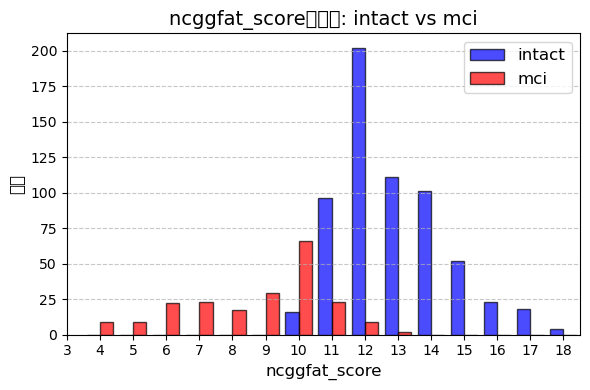

===== intact群の統計量 =====
データ数: 623
平均値: 12.88
標準偏差: 1.61
最小値: 10
最大値: 18

===== mci群の統計量 =====
データ数: 209
平均値: 8.70
標準偏差: 2.11
最小値: 4
最大値: 13


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# DataFrameに変換


# グループごとにデータを分ける
intact_scores = df5[df5['ncggfat_label'] == 'intact']['ncggfat_score']
mci_scores = df5[df5['ncggfat_label'] == 'mci']['ncggfat_score']

# ヒストグラムの設定
plt.figure(figsize=(6, 4))

# ビンの数を適切に設定（少ないデータなので調整）
bins = np.arange(min(df5['ncggfat_score'])-0.5, max(df5['ncggfat_score'])+1.5, 1)

# 2つのヒストグラムを重ねて表示
plt.hist([intact_scores, mci_scores], bins=bins, alpha=0.7, 
         label=['intact', 'mci'], color=['blue', 'red'], edgecolor='black')

# グラフの装飾
plt.title('ncggfat_scoreの分布: intact vs mci', fontsize=14)
plt.xlabel('ncggfat_score', fontsize=12)
plt.ylabel('頻度', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 軸の範囲を設定
plt.xlim(min(bins), max(bins))
plt.xticks(range(int(min(bins)), int(max(bins))+1))

plt.tight_layout()
plt.show()

# 基本統計量も表示
print("===== intact群の統計量 =====")
print(f"データ数: {len(intact_scores)}")
print(f"平均値: {intact_scores.mean():.2f}")
print(f"標準偏差: {intact_scores.std(ddof=0):.2f}")
print(f"最小値: {intact_scores.min()}")
print(f"最大値: {intact_scores.max()}")

print("\n===== mci群の統計量 =====")
print(f"データ数: {len(mci_scores)}")
print(f"平均値: {mci_scores.mean():.2f}")
print(f"標準偏差: {mci_scores.std(ddof=0):.2f}")
print(f"最小値: {mci_scores.min()}")
print(f"最大値: {mci_scores.max()}")

NameError: name 'df4' is not defined

In [13]:
df5=pd.merge(df4, df1, on = 'ID2', how = 'inner')
df5.head()

,InspectionDateAndId,ID,ID2,ncggfat_score,ncggfat_label_x,eye_side,ins_comp_status,input,age,ins_path,...,direction_change_frequency,high_freq_power,freq,power_spectrum,manhattan_distance_sum,manhattan_distance_mean,euclidean_distance_sum,euclidean_distance_mean,ncggfat_score_x,ncggfat_label_y
0,20241009101605_1,1,101055733,16,intact,right,30,0,80,G:/共有ドライブ/GAP_長寿研/GAPデータ/20241009101605_1,...,28.689592,2.275089e+07,[ 0.0325648 0.06512961 0.09769441 0.130259...,[ 15987.17842306 64871.16182971 30437.013670...,7.872284e+05,457.424972,629641.7733,365.858090,16,intact
1,20241009101953_2,2,101055733,16,intact,left,30,0,80,G:/共有ドライブ/GAP_長寿研/GAPデータ/20241009101953_2,...,29.644545,6.051234e+07,[2.79665520e-02 5.59331040e-02 8.38996560e-02 ...,[ 13376.59072991 103577.55288196 252609.042419...,1.113498e+06,514.793367,797790.0975,368.834996,16,intact
2,20241009110727_26,26,101013200,6,mci,right,30,0,82,G:/共有ドライブ/GAP_長寿研/GAPデータ/20241009110727_26,...,24.547398,8.210293e+05,[ 0.03143073 0.06286145 0.09429218 0.125722...,[ 5840.7272009 9351.58093013 6698.3111861 ...,8.571302e+05,484.528090,702949.1877,397.370937,6,mci
3,20241009111206_29,29,101013200,6,mci,left,30,0,82,G:/共有ドライブ/GAP_長寿研/GAPデータ/20241009111206_29,...,22.962343,3.788913e+07,[ 0.0334728 0.06694561 0.10041841 0.133891...,[232029.92983684 206739.04616262 158514.197300...,8.810219e+05,519.164372,627045.7913,369.502529,6,mci
4,20241009114326_50,50,101059340,18,intact,right,30,0,76,G:/共有ドライブ/GAP_長寿研/GAPデータ/20241009114326_50,...,25.719479,6.986289e+07,[ 0.03029385 0.0605877 0.09088155 0.121175...,[ 97505.16853413 212987.56795455 54731.168009...,7.755362e+05,417.628548,612567.7671,329.869557,18,intact


In [14]:
df5.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\meta_combined_saccade_analysis_15_mciintact456161718.csv')

In [16]:
df4.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\meta_combined_saccade_analysis_15_456161718.csv')

In [68]:
df8.to_csv(r'G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\data\meta_combined_saccade_analysis_15_mci.csv')